###Q1 - Distribuição da Soma

- Considerar $M$ dados que são jogados, podendo sair números do 1 até o 6. A soma dos valores será a fórmula abaixo em que $d_i$ é o número que saiu em cada um dos dados. Jogar os $M$ dados $N$ vezes e construir um histograma que mostre o comportamento de $S$.

$$S = \sum_{i=1}^{M} d_i$$

- Desenvolver um código de python que grafica os histogramas que permitam visualizar como a variável aleatória $S$ está distribuída.

- Generalizar o código para que o cálculo esteja dentro de uma função, a qual deve receber os valores de $N$ e $M$;

- Elaborar os histogramas varrendo diferentes valores de $N$ ($10^2, 10^3, 10^4, 10^5, 10^6, 10^7$) e de $M$ (2, 4, 8).

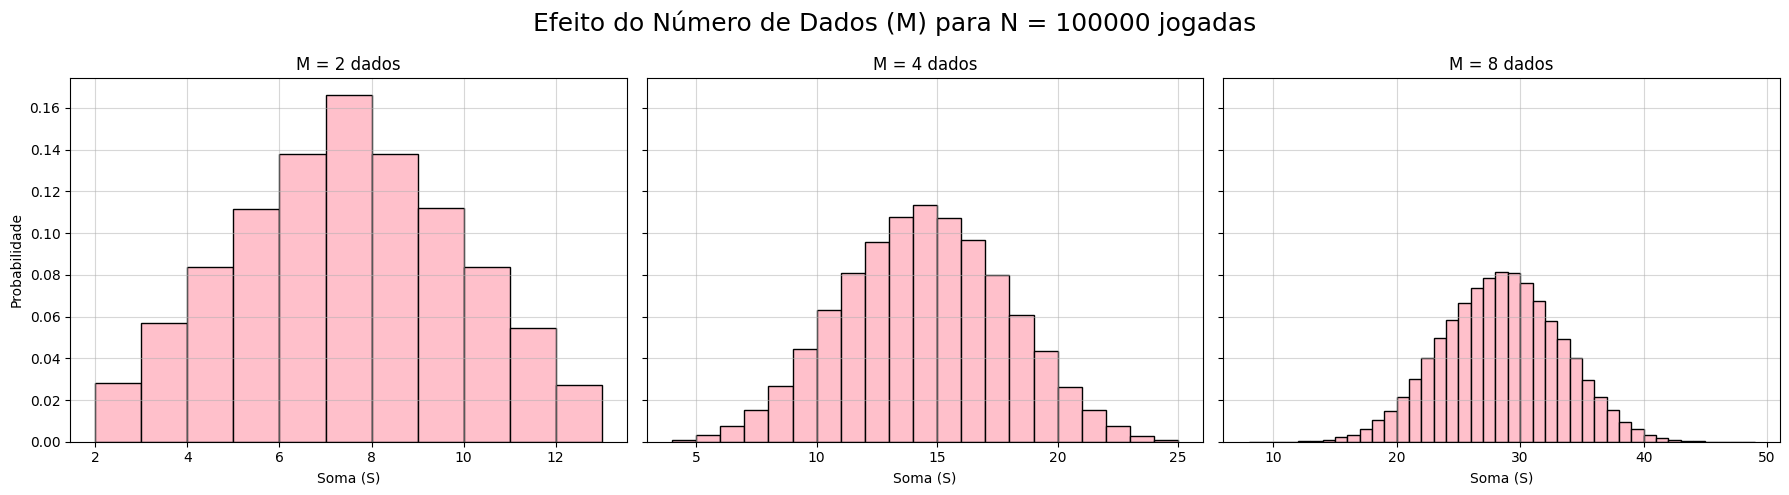

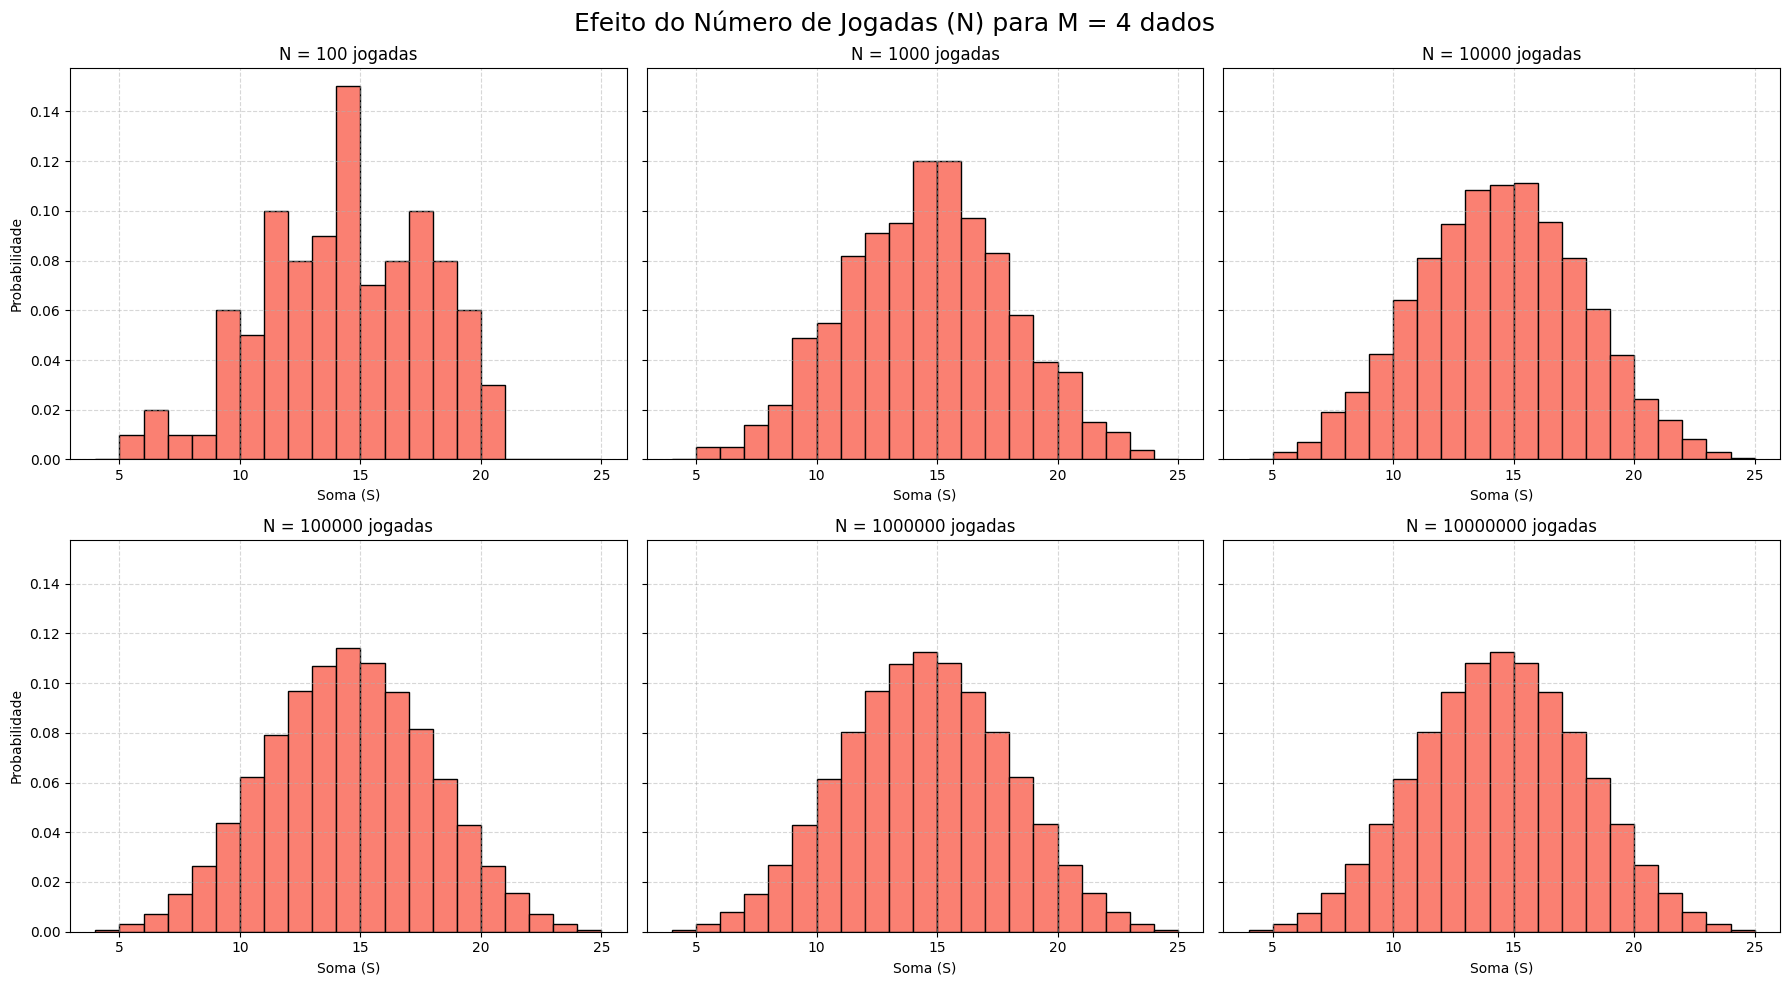

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# FUNÇÃO

# criar uma função que recebe dois valores (a quantidade de dados N e o numero de repetiçoes M)
def somas_dados(N, M):
  # criar uma matriz N (linha), M (coluna)
  lancamentos = np.random.randint(low=1, high=7, size=(N, M))
  # somando todos os valores da mesma linha (soma M valores)
  # axis=1 é linha e axis=0 é coluna
  somas = np.sum(lancamentos, axis=1)
  # a função retorna um array com as N somas
  return somas

# CASO 1:

# manter fixo N e variar o numeros de dados para analisar o comportamento de S
M_valores = [2, 4, 8]
N_fixo = 100000

# criar uma figura com um subplot pra cada M
fig, axes = plt.subplots(1, len(M_valores), figsize=(18, 5), sharey=True)
# o sharey define o mesmo eixo y para todos os subplots para comparar as probabilidades
fig.suptitle(f'Efeito do Número de Dados (M) para N = {N_fixo} jogadas', fontsize=18)

# o enumerate retorna o indice i e o valor de indice M
for i, M in enumerate(M_valores):
  # usando a função para esse M
  S = somas_dados(N_fixo, M)
  # definir o subplot que ele vai usar
  ax = axes[i]

  # definir os limites das caixas
  min_soma = M # (sair 1 em cada)
  max_soma = 6 * M # (sair 6 em cada)
  # criando as caixas
  # o histograma termina onde a ultima caixa começa e o range vai ate (fim -1) por isso tem que colocar +2 no final
  bins = range(min_soma, max_soma + 2)
  # plotar o histograma (dados, como quero agrupar)
  # ao inves do eixo y mostrar o resultado da soma, ela mostra a porcentagem de vezes em relaçao ao total que aquele valor apareeceu
  ax.hist(S, bins=bins, density=True, edgecolor='black', color='pink')

  ax.set_title(f'M = {M} dados')
  ax.set_xlabel('Soma (S)')
  ax.grid(True, alpha=0.5)

# colocando o nome do eixo y so no primeiro subplot pois eles compartilham o mesmo
axes[0].set_ylabel('Probabilidade')


plt.tight_layout()
plt.show()


# CASO 2:

N_valores = [10**2, 10**3, 10**4, 10**5, 10**6, 10**7]
M_fixo = 4

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
axes = axes.flatten() # transforma a matriz de eixos em uma lista simples

fig.suptitle(f'Efeito do Número de Jogadas (N) para M = {M_fixo} dados', fontsize=18)

for i, N in enumerate(N_valores):
  S = somas_dados(N, M_fixo)
  ax = axes[i]

  min_soma = M_fixo
  max_soma = 6 * M_fixo
  bins = range(min_soma, max_soma + 2)

  ax.hist(S, bins=bins, density=True, color='salmon', edgecolor='black')
  ax.set_title(f'N = {N} jogadas')
  ax.set_xlabel('Soma (S)')
  ax.grid(True, alpha=0.5, ls="--")

  # adicionar o rótulo do eixo Y apenas se o gráfico estiver na primeira coluna
  if i % 3 == 0: # so i=0 e i=3
    ax.set_ylabel('Probabilidade')

plt.tight_layout()
plt.show()

###Q2 - Monte Carlo para $\pi$

- Elaborar um código de cálculo que implementa o método Monte Carlo para calcular o número $\pi$. Para isto, encapsular todos os cálculos dentro de uma função que possa ser chamada especificando o número de realizações;

- Elaborar uma tabela de resultados similar à mostrada acima;

- Para cada valor de $N$, realizar uma média do resultado obtido em cada execução do experimento, e plotar o erro em escala loglog do resultado (i.e., $|\pi - \pi_{MC}|$) como função de $N$.

- Monte Carlos: A proporção de dardos que caem dentro do círculo em relação ao número total de dardos jogados será aproximadamente igual à proporção da área do círculo em relação à área do quadrado.Essa razão de áreas é aproximadamente igual à razão dos "dardos" (pontos aleatórios):

$$ \frac{A_{círculo}}{A_{quadrado}} = \frac{\pi}{4} $$

$$ \frac{\text{Número de pontos no círculo }(N_c)}{\text{Número total de pontos }(N)} \approx \frac{\pi}{4} $$


$$ \pi \approx 4 \times \frac{N_c}{N} $$

<>:90: SyntaxWarning: invalid escape sequence '\p'
<>:92: SyntaxWarning: invalid escape sequence '\p'
<>:90: SyntaxWarning: invalid escape sequence '\p'
<>:92: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-4039485816.py:90: SyntaxWarning: invalid escape sequence '\p'
  plt.title('Erro da Estimativa de $\pi$ pelo Método Monte Carlo')
/tmp/ipython-input-4039485816.py:92: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('Erro Absoluto ($|\pi - \pi_{MC}|$)')


---------------------------------------------------------------
                            TABELA                             
                                                               
   N = 1000  N = 10000  N = 100000  N = 1000000  N = 10000000
1   3.12800    3.17760     3.15296      3.14092       3.14215
2   3.18400    3.14400     3.14124      3.14180       3.14220
3   3.12400    3.14680     3.13664      3.14281       3.14106
4   3.20800    3.14560     3.15148      3.14169       3.14168
---------------------------------------------------------------


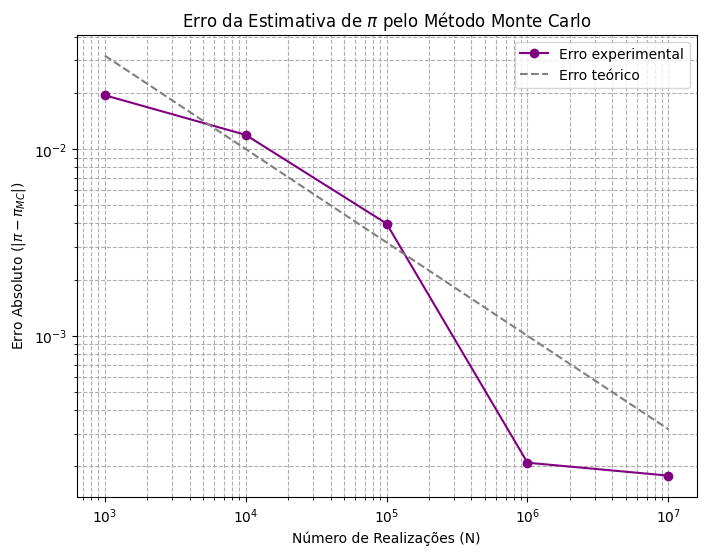

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd # criar tabelas

# 1. CRIAR A FUNÇÃO

def estima_pi(N):
  # sorteia N numeros aleatórios entre -1 e 1
  # aqui cria um quadrado de lado 2
  x = np.random.uniform(-1, 1, N) # cria um array de N valores float
  y = np.random.uniform(-1, 1, N)
  # ele faz a operação de cada valor de mesmo indice dos dois arrays, criando um novo array
  distancia_quadrada = x**2 + y**2
  # aqui verifica se o ponto esta no circulo de raio 1
  # cria um array booleano, trata true como 1 e false como 0, e soma tudo achando a quantidade de pontos true
  Nc = np.sum(distancia_quadrada <= 1)
  # calcula pela logica de monte carlos
  pi_estimado = 4 * Nc / N

  return pi_estimado

# 2. ACHAR OS VALORES

# criar uma tabela onde cada N seja executado 4 vezes
valores_N = [10**3, 10**4, 10**5, 10**6, 10**7]
rep = 4

# criar um dicionario para cada chave N e seus 4 valores
dicionario_N = {}
# lista com a média de cada N
lista_medias = []
# lista com o erro médio de cada N
lista_erros = []

# achar os valores de cada N
for N in valores_N:
  # vai criar uma lista dos 4 resultado
  resultados_N = []
  for i in range(rep):
    pi = estima_pi(N)
    resultados_N.append(pi)
    # acrescenta esse valor em sua chave N
    dicionario_N[f'N = {N}'] = resultados_N

  # após finalizar a lista temporaria, calcula a media dos valores dela
  media = np.mean(resultados_N)
  # acrescenta na lista de médias
  lista_medias.append(media)
  # usa o valor médio desse N para calcular o erro desse N
  erros = np.abs(np.pi - media)
  # acrescenta na lista de erros
  lista_erros.append(erros)


# 3. MONTAR A TABELA DOS VALORES DE N

# essa função do pandas vetoriza os dados (ele percorre os valores da lista sem usar for)
# ele utiliza as chaves como os nomes das colunas, e os dados ded cada chave como os valores de cada coluna
tabela = pd.DataFrame(dicionario_N)
# o índice por padrão começa com 0 e eu quero que comece com 1
tabela.index = [i+1 for i in range(rep)]

print('---------------------------------------------------------------')
print('                            TABELA                             ')
print('                                                               ')
print(tabela.to_string(float_format="%.5f"))
print('---------------------------------------------------------------')

# 4. MONTAR O GRÁFICO

plt.figure(figsize=(8, 6))

# plotar a lista dos valores_N no eixo x e a lista dos erros no eixo y
# como são duas linhas, vou colocar aqui tbm o nome dessa linha que vai aparecer na legenda (label)
# o marker vai marcar o valor daquele dado e depois o line vai ligar os pontinhos
# ao trocar "plot" por "loglog" ja muda direto pro loglog (tem tbm o semilogx, semilogy)
plt.loglog(valores_N, lista_erros, marker='o', linestyle='-', color='purple', label='Erro experimental')


# o erro teórico é a a curva ideal que preve o erro de processos aleatorios
# ele diz que o erro diminui conforme o numero de realizações aumenta na proporção de (1/√N)
# fazer uma nova lista agora dos erros teoricos para cada N
erro_teorico = 1 / np.sqrt(valores_N)
# plotar o grafico do erro teorico pra comparar
plt.loglog(valores_N, erro_teorico, linestyle='--', color='gray', label=r'Erro teórico')

plt.title('Erro da Estimativa de $\pi$ pelo Método Monte Carlo')
plt.xlabel('Número de Realizações (N)')
plt.ylabel('Erro Absoluto ($|\pi - \pi_{MC}|$)')
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()

###Q3 - Soma de Riemann para $\pi$

- Implementar o cálculo de número $\pi$ usando um método da soma de Riemann (i.e., um método determinístico). Para isto considerar a soma de Riemann em que $f(x) = \sqrt{1 - x^2}$ e $\Delta x = 1/N$, sendo $N$ o número de subintervalos e $x_i = i \Delta x$. Claramente, $\lim_{N\to\infty} S_R = \frac{\pi}{4}$.

$$S_R = \sum_{i=1}^{N} f(x_i) \Delta x$$


- Considerar diferentes valores de $N$ e calcular o erro como função de $N$ comparando com o valor de $\pi$ conhecido.
- Plotar e/ou fazer uma tabela para reportar os resultados.

--------------------------------------------
         Tabela dos Resultados               
                                             
 Valor de N  Valor de π  Erro absoluto
         10    2.904518       0.237074
        100    3.120417       0.021176
       1000    3.139555       0.002037
      10000    3.141391       0.000201
     100000    3.141573       0.000020
    1000000    3.141591       0.000002
--------------------------------------------


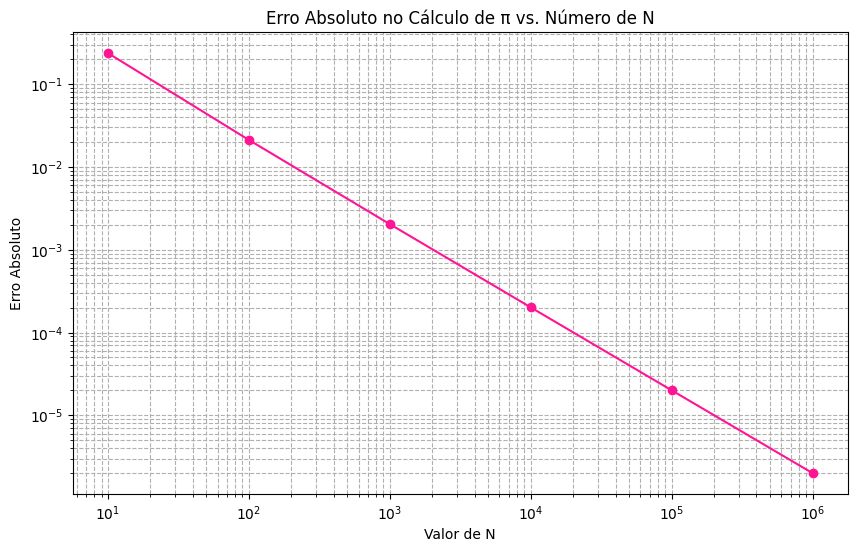

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. CALCULAR VALORES

valores_N = [10, 100, 1000, 10000, 100000, 1000000]

valores_pi_R = []
lista_erros = []

for N in valores_N:
  delta_x = 1/N
  soma = 0
  for i in range(1, N + 1):
    x_i = i*delta_x
    f_xi = np.sqrt(1-x_i**2)
    soma += f_xi
  S_R = soma * delta_x

  # como essa soma se aproxima de pi/4:
  pi_R = 4 * S_R
  valores_pi_R.append(pi_R)
  # calcular o erro desse pi com o verdadeiro
  erro = abs(pi_R - np.pi)
  lista_erros.append(erro)


# 2. CRIAR A TABELA

# crinando o dicionario pro pandas usar
dicionario_SR = {'Valor de N': valores_N, 'Valor de π': valores_pi_R, 'Erro absoluto': lista_erros}
tabela = pd.DataFrame(dicionario_SR)

print('--------------------------------------------')
print("         Tabela dos Resultados               ")
print('                                             ')
# .to_string() converte a tabela inteira pra formato de texto e diz pra ignorar a coluna de índice e depois mostrar o texto
print(tabela.to_string(index=False))
print('--------------------------------------------')

# 3. CRIAR O GRÁFICO

plt.figure(figsize=(10, 6))
plt.loglog(valores_N, lista_erros, marker='o', linestyle='-', color='deeppink')

plt.title('Erro Absoluto no Cálculo de π vs. Número de N')
plt.xlabel('Valor de N')
plt.ylabel('Erro Absoluto')

plt.grid(True, which="both", ls="--")
plt.show()

###Q4 - Área via Monte Carlo

- Considerar as funções $f(x) = 1 + \frac{1}{2} \sin^3(2x)$ e $g(x) = 3 + \frac{1}{2} \cos^5(3x)$ no intervalor $[0, 2\pi]$.

- Plotar as funções.
- Usando uma tabela de integrais ou algum programa para cálculo simbólico (p.e., Mathematica) calcular a área entre as duas curvas.
- Calcular com um método Monte Carlo a área entre as duas curvas e comparar com o item anterior. O programa dever plotar

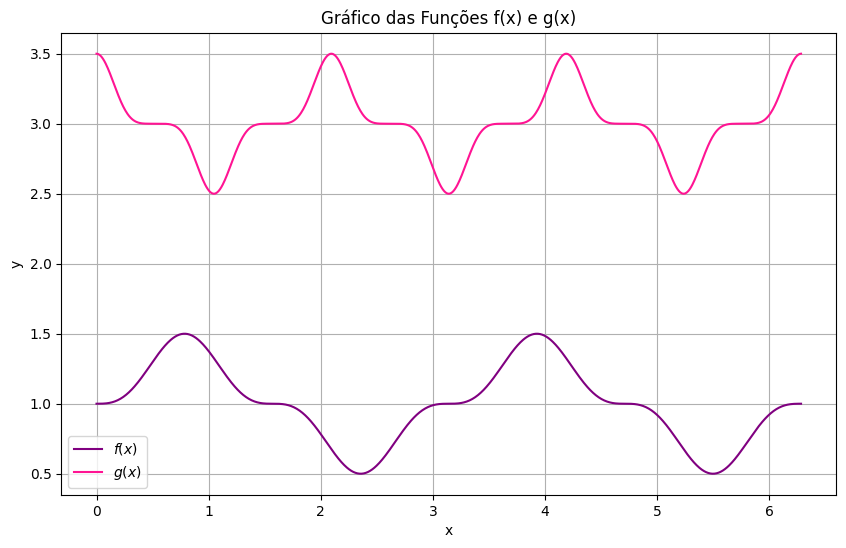

--------------------------------------------------------
O valor da área pelo cálculo da integral é: 12.56637
--------------------------------------------------------
O valor da área estimada pelo Método Monte Carlo é: 12.55833
--------------------------------------------------------


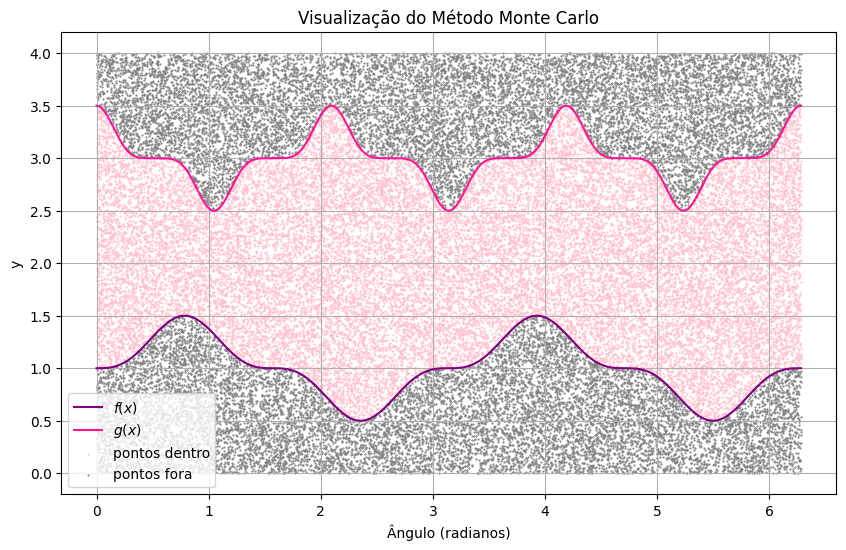

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

# 1. CRIAR AS FUNÇÕES

def f(x):
  return 1 + 0.5 * (np.sin(2 * x))**3

def g(x):
  return 3 + 0.5 * (np.cos(3 * x))**5

# 2. PLOTAR OS GRÁFICOS

# criando um array de 0 a 2pi dividido em 1000 valores
eixo_x = np.linspace(0, 2 * np.pi, 1000)
eixoy_f = f(eixo_x)
eixoy_g = g(eixo_x)

# usar a mesma figura para criar duas curvas
plt.figure(figsize=(10, 6))
plt.plot(eixo_x, eixoy_f, label='$f(x)$', color='purple')
plt.plot(eixo_x, eixoy_g, label='$g(x)$', color='deeppink')

plt.title('Gráfico das Funções f(x) e g(x)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

# calcular o valor da integral de 0 a 2*pi de g(x)-f(x)
def diferenca(x):
  return g(x) - f(x)

# a função quad sempre retorna o resultado e o erro
area, erro = scipy.integrate.quad(diferenca, 0, 2*np.pi)

print("--------------------------------------------------------")
print(f"O valor da área pelo cálculo da integral é: {area:.5f}")
print("--------------------------------------------------------")

# 3. MÉTODO MONTE CARLO

# escolher a quantidade de dardos que vamos jogar
N = 50000

pontos_dentro = 0
x_dentro, y_dentro = [], []
x_fora, y_fora = [], []

for i in range(N):
  # gerar pontos aleatorios dentro do "quadrado"
  ponto_x = np.random.uniform(0, 2*np.pi)
  ponto_y = np.random.uniform(0, 4)
  # verificar se o ponto está entre as duas curvas
  if f(ponto_x) < ponto_y < g(ponto_x):
    pontos_dentro += 1
    x_dentro.append(ponto_x)
    y_dentro.append(ponto_y)
  else:
    x_fora.append(ponto_x)
    y_fora.append(ponto_y)

# área maior
area_maior = 4*(2*np.pi)

# pela relação monte carlos
area_menor = area_maior * (pontos_dentro / N)

print(f"O valor da área estimada pelo Método Monte Carlo é: {area_menor:.5f}")
print("--------------------------------------------------------")

# 4. PLOTAR O GRÁFICO DO MÉTODO MONTE CARLO

# refazer o gráfico acima
plt.figure(figsize=(10, 6))
plt.plot(eixo_x, eixoy_f, label='$f(x)$', color='purple')
plt.plot(eixo_x, eixoy_g, label='$g(x)$', color='deeppink')

# fazendo o gráfico dos pontinhos (scatter)
plt.scatter(x_dentro, y_dentro, color='pink', s=0.3, label='pontos dentro')
plt.scatter(x_fora, y_fora, color='gray', s=0.3, label='pontos fora')

plt.title('Visualização do Método Monte Carlo')
plt.xlabel('Ângulo (radianos)')
plt.ylabel('y')
plt.grid(True)
plt.legend()

plt.show()


###Q5 - Área Complexa via Monte Carlo

- Considerar as mesmas funções do exercício anterior mas agora considerar que a esquerda e a direita a região está limitada por uma parábola como mostrado na figura.

- A parábola da esquerda passa pelos pontos $[0, 1]$, $[-1, 2.25]$, $[0, 3.5]$ e a parábola de direita passa pelos pontos $[2\pi, 1]$, $[2\pi+1, 2.25]$, $[2\pi, 3.5]$.

- Plotar a região considerada graficando as funções correspondentes.
- Calcular a área de região considerada usando o método Monte Carlo e tabelar o resultado como função do número de pontos sendo jogados. O programa dever plotar os pontos que caíram fora e dentro da região.

----------------------------------------------------------------------
O valor da área estimada pelo Método Monte Carlo é: 15.85091
----------------------------------------------------------------------


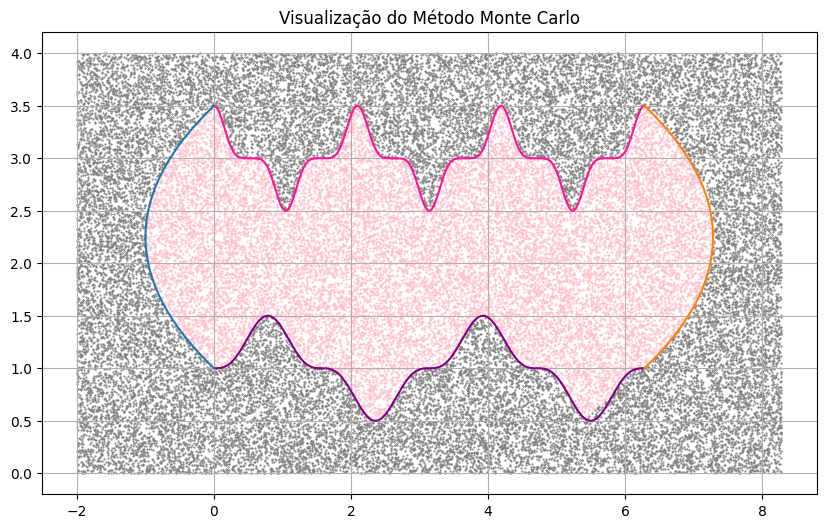

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt

# 1. CRIANDO A FUNÇÃO DAS PARÁBOLAS

# criar a função que vai me da os coeficientes a,b,c da equação de 2 grau das parabolas
def calcula_coeficientes(pontos):
  # desempacotar os itens do dicionario de pontos que tem 3 chaves com dois itens cada (coord)
  p1, p2, p3 = pontos
  x1, y1 = p1
  x2, y2 = p2
  x3, y3 = p3
  # vamos obter um sistema com uma equação para cada ponto do tipo x=a*(y**2)+b*y+c
  # trocar x por y pois essas parabolas sao inversas
  # montar uma matriz com os coeficientes das equações
  matriz_A = np.array([[y1**2, y1, 1],[y2**2, y2, 1],[y3**2, y3, 1]])
  vetor_B = np.array([x1, x2, x3])
  # o sistema linear é representado assim: vetor_B = matriz_A * (a,b,c)
  # o linalg.solve() resolve um sistema linear
  # primeiro coloca a matriz dos coeficiente, e depois o vetor do resultado e ela vai da qual vetor satisfaz esse sistema
  coeficientes = np.linalg.solve(matriz_A, vetor_B)
  # como esses valores sao definitivos e imutaveis, vamos retornar como uma tupla
  return tuple(coeficientes)

# 2. MÉTODO MONTE CARLO

# pegando as funções das curvas
def f(x):
  return 1 + 0.5*(np.sin(2 * x))**3
def g(x):
  return 3 + 0.5*(np.cos(3 * x))**5

# pegando os dados das parabolas
parabolas = {
  "P_esq": [[0, 1], [-1, 2.25], [0, 3.5]],
  "P_dir": [[2*np.pi, 1], [2*np.pi + 1, 2.25], [2*np.pi, 3.5]]
}

# definindo os coeficientes das parabolas
a_esq, b_esq, c_esq = calcula_coeficientes(parabolas["P_esq"])
a_dir, b_dir, c_dir = calcula_coeficientes(parabolas["P_dir"])

# quantidade pontinhos que vamos jogar
N = 50000

pontos_dentro = 0 # usar pra achar a area
# definir as coord dos pontos dentro e fora
x_dentro, y_dentro = [], []
x_fora, y_fora = [], []

for i in range(N):
  # gerar pontos aleatorios dentro da area maior
  ponto_x = np.random.uniform(-2, 2*np.pi+2)
  ponto_y = np.random.uniform(0, 4)

  # verificar as condições que fazem os pontos estarem dentro das parabolas
  cond1 = ponto_x < (a_dir * ponto_y**2) + (b_dir * ponto_y) + c_dir
  cond2 = ponto_x > (a_esq * ponto_y**2) + (b_esq * ponto_y) + c_esq

  if 0 <= ponto_x <= 2*np.pi:
    # apenas nessa regiao que a condição 3 deve valer
    cond3 = f(ponto_x) < ponto_y < g(ponto_x)
    if cond1 and cond2 and cond3:
      pontos_dentro += 1
      x_dentro.append(ponto_x)
      y_dentro.append(ponto_y)
    else:
      x_fora.append(ponto_x)
      y_fora.append(ponto_y)
  else:
    # nas regiões laterais as curvas nao aparecem
    if cond1 and cond2:
      pontos_dentro += 1
      x_dentro.append(ponto_x)
      y_dentro.append(ponto_y)
    else:
      x_fora.append(ponto_x)
      y_fora.append(ponto_y)

# calcular a area maior
area_maior = 4*(2*np.pi+4)
# pela relação monte carlos:
area_menor = area_maior * (pontos_dentro / N)

print("----------------------------------------------------------------------")
print(f"O valor da área estimada pelo Método Monte Carlo é: {area_menor:.5f}")
print("----------------------------------------------------------------------")

# 3. CRIANDO O GRÁFICO

# desenhando as curvas
fig, axx = plt.subplots(figsize=(10, 6))
# definindo o eixo x
eixo_x = np.linspace(0, 2*np.pi, 20000)
# eixo y da função f(x)
eixoy_f = f(eixo_x)
plt.plot(eixo_x, eixoy_f, color='purple')
# eixo y da função g(x)
eixoy_g = g(eixo_x)
plt.plot(eixo_x, eixoy_g, color='deeppink')

# criar uma função que dado um subplot, os coef e os pontos da parabola, desenhe essa parabola
def plotar_parabola(axx, coeficientes, pontos):
  a, b, c = coeficientes
  y_pontos = [p[1] for p in pontos]
  y_min, y_max = min(y_pontos), max(y_pontos)
  eixo_y = np.linspace(y_min, y_max, 400)
  eixo_x = a * eixo_y**2 + b * eixo_y + c
  linha = axx.plot(eixo_x, eixo_y)

for nome, lista_de_pontos in parabolas.items():
  coef = calcula_coeficientes(lista_de_pontos)
  plotar_parabola(axx, coef, lista_de_pontos)

# pintando os pontinhos dentro e fora
plt.scatter(x_dentro, y_dentro, color='pink', s=0.3)
plt.scatter(x_fora, y_fora, color='gray', s=0.3)

plt.title('Visualização do Método Monte Carlo')
plt.grid(True)

plt.show()



###Q6 - Cálculo de $\pi$ em 3D

- Calcular o número $\pi$ usando a técnica Monte Carlo mas agora trabalhando em três dimensões jogando pontos aleatórios dentro do cubo $[-1, 1] \times [-1, 1] \times [-1, 1]$ e considerando a esfera de raio 1 inscrita no cubo:

- Fazer uma tabela para plotar os resultados como função do número de pontos $N$ e avaliar o erro.
- Plotar os pontos num gráfico 3D tentando ajustar a transparência dos pontos que ficam fora da esfera para poder enxergar os pontos dentro da esfera.
- Tentar melhorar a eficiência do código vetorizando ele

 Valor de N π estimado      Erro
        100  3.1800000 0.0384073
       1000  3.0840000 0.0575927
      10000  3.1662000 0.0246073
     100000  3.1539600 0.0123673
    1000000  3.1507980 0.0092053
   10000000  3.1412082 0.0003845


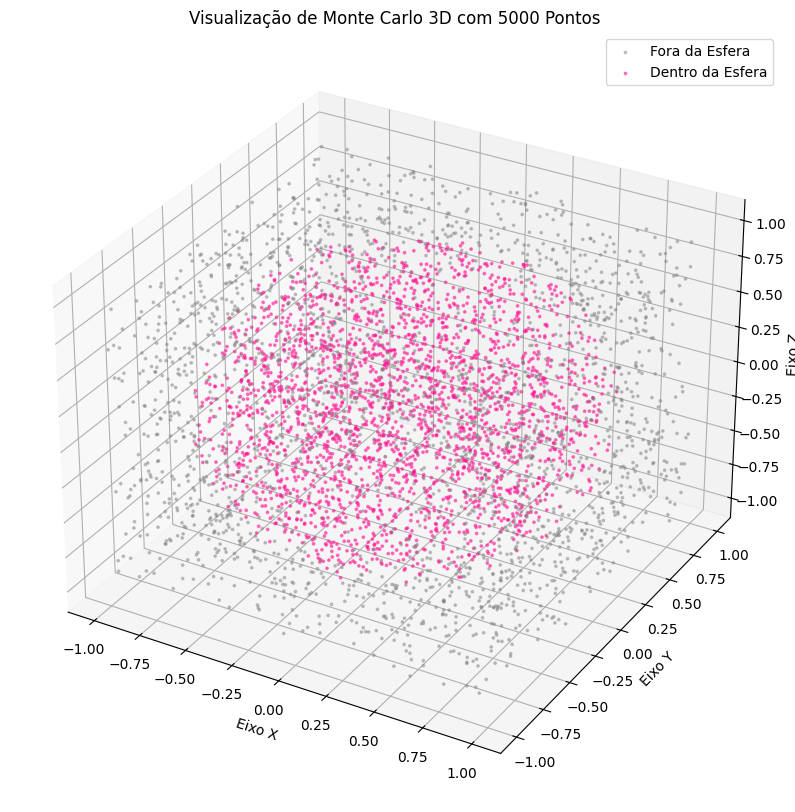

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# IMPORTANTE: Vetorização é aplicar uma operação a um array inteiro de uma vez,
# em vez de aplicar a operação a cada elemento individualmente dentro de um loop for.


# 1. CRIAR A FUNÇÃO MONTECARLO EM 3D

# criando uma função que recebe o valor de N
def monte_carlo_3d(N):
  # essa função cria uma matriz NxM
  # que gera N pontos (linhas) com M coords (colunas) aleatorios entre 0 e 1
  # mudando os limites dos numeros: (2 *) --> 0 e 2, (-1) --> -1 e 1
  pontos = 2 * np.random.rand(N, 3) - 1
  # verificar quais pontos estão dentro da esfera de raio 1
  # eleva cada numero de uma LINHA (axis=1) ao quadrado e depois soma eles
  # condição é x**2+y**2+z**2≤1
  dist = np.sum(pontos**2, axis=1)
  # cria um array booleano
  dentro_da_esfera = dist <= 1
  # conta quantos True tem no array
  N_dentro = np.sum(dentro_da_esfera)

  # o metodo montecarlo 3d sera:
  # volume menor/ volume maior = N_dentro/ N_total
  # volume menor (esfera) de raio R = (4*pi*R**3)/3
  # volume maior (cubo) de lado 2R = (2*R)**3
  # portanto vol esfera/ vol cubo = pi/6
  # pi ≈ 6 * (N_dentro / N_total)
  pi_estimado = 6 * N_dentro / N

  # retorna o valor de pi, a matriz(Nx3) e o mapa de quais linhas sao true
  return pi_estimado, pontos, dentro_da_esfera


# 2. CRIAR A TABELA

# define a lista de número de pontos para testar
valores_N = [10**2, 10**3, 10**4, 10**5, 10**6, 10**7]
resultados = []

for n in valores_N:
  # aqui quero so o valor de pi para esse N usando a função (que gera 3 resultados)
  pi_calculado, a, b = monte_carlo_3d(n)
  # calcular o erro desse pi
  erro = abs(pi_calculado - np.pi)
  # criar o dicionario para usar o pandas
  resultados.append({
      "Valor de N": n,
      "π estimado": f"{pi_calculado:.7f}",
      "Erro": f"{erro:.7f}"
  })

# criar a tabela
tabela_df = pd.DataFrame(resultados)
# tirar a coluna dos índices
print(tabela_df.to_string(index=False))


# 3. CRIAR O GRÁFICO

pontinhos = 5000
a, matriz_pontos, dentro_esfera = monte_carlo_3d(pontinhos)

# cria uma nova matriz contendo apenas as coord que acertaram
pontos_dentro = matriz_pontos[dentro_esfera]
# o ~ inverte o true e false e cria a nova matriz dos coord fora
pontos_fora = matriz_pontos[~dentro_esfera]

# criando a moldura
fig = plt.figure(figsize=(10, 10))
# definindo o conjunto de eixos usando o axes3d
# ele da a capacidade de plotar em 3 dim
ax = fig.add_subplot(1, 1, 1, projection='3d')

# plotar os pontos de fora
# ":" --> percorra todas as linhas
# o numero depois da virgula indica qual coluna
#                eixo x [0]        eixo y [1]         eixo z [3]
ax.scatter(pontos_fora[:, 0], pontos_fora[:, 1], pontos_fora[:, 2], c='gray', alpha=0.4, label='Fora da Esfera', s=3)

# Plota os pontos de dentro
ax.scatter(pontos_dentro[:, 0], pontos_dentro[:, 1], pontos_dentro[:, 2], c='deeppink', alpha=0.5, label='Dentro da Esfera', s=3)

# Configurações do gráfico
ax.set_title(f'Visualização de Monte Carlo 3D com {pontinhos} Pontos')
ax.set_xlabel('Eixo X')
ax.set_ylabel('Eixo Y')
ax.set_zlabel('Eixo Z')
ax.legend()


###Q7 - Probabilidade de Sequências

- Considerar uma moeda "justa" que é jogada no ar $N$ vezes, pudendo sair cara ou cruz. Fazer um algoritmo para estimar a probabilidade de que saim $n$ caras seguidas. Considerar por exemplo $N = 10$ e $20$ e $n = 3$ e $5$. Será necessário pensar no algoritmo para detetar dentro de um vetor a ocorrência de $n$ caras seguidas. O experimento deverá ser realizado dezenas de milhares de bases para estimar a probabilidade como

$$p = \frac{N_{\text{casos de sucesso}}}{N_{\text{experimentos}}}$$

- Não considerar sobreposições, ou seja, com que a sequência se repita apenas 1 vez as $n$ vezes dentro dos $N$ lançamentos, já se considera caso de sucesso.

In [ ]:
import numpy as np

# essa função vai pegar uma lista de 0 (coroa) e 1 (cara)
# ela vai procurar o valor "1", ao encontrar ela soma mais 1
# se o proximo for zer ela zera a lista novamente
# caso atinja um certo valor n de caras seguidas ela trava e retorna true
# caso nao, ela continua ate acabar a sequencia
# se nao achar n "1" seguidos ele retorna false

def verificar_sequencia(lancamentos, n):
  caras_seguidas = 0
  for i in lancamentos:
    if i == 1:
      caras_seguidas += 1
    else:
      caras_seguidas = 0
    # assim que encontrar uma sequencia, ela trava
    if caras_seguidas >= n:
      return True
  # se a sequencia nunca retornar true, ela eh false
  return False

# essa função vai verificar quantos caso de sucesso por numero de casos tem
# N é a quantidade de 0 e 1 tem na sequencia
# n é a quantidade de "1" que eu quero que repita
# num é quantas vezes eu vou sortear uma nova sequencia de N valores 0 e 1
def calcular_prob(N, n, num):
  casos_de_sucesso = 0
  for i in range(num):
    # criando um array de N valores de 0 e 1 aleatoriamente
    lancamentos = np.random.randint(0, 2, size=N)
    # usa a função acima pra verificar se essa sequencia é true ou false
    # ou seja que essa sequencia corresponde a uma caso de sucesso
    if verificar_sequencia(lancamentos, n):
      casos_de_sucesso += 1
  # retorna a probabilidade que é de todos as vezes que sorteei, quantas sequencias foram válidas
  return casos_de_sucesso / num

rep = 50000
valores_N = [10, 20]
valores_n = [3, 5]

print(f"Executando simulação com {rep} experimentos para cada caso.\n")

for N in valores_N:
  for n in valores_n:
    prob = calcular_prob(N, n, rep)
    print(f"Para N = {N} lançamentos e n = {n} caras seguidas:")
    print(f"Probabilidade estimada: {prob:.2%}\n")

Executando simulação com 50000 experimentos para cada caso.

Para N = 10 lançamentos e n = 3 caras seguidas:
Probabilidade estimada: 50.84%

Para N = 10 lançamentos e n = 5 caras seguidas:
Probabilidade estimada: 10.71%

Para N = 20 lançamentos e n = 3 caras seguidas:
Probabilidade estimada: 78.69%

Para N = 20 lançamentos e n = 5 caras seguidas:
Probabilidade estimada: 25.07%



###Q8 - Caminhada Aleatória em Grafo

- Considerar um grafo com $N$ nós, por exemplo, o grafo na sequência:

$$edges = [(0, 1), (1, 3), (1, 2), (2, 4), (2, 6), (6, 5), (6, 7), (7, 8), (8, 9)]$$

- (i) Considerar uma partícula que entra no nó 0 e precisa sair pelo nó $N - 1$.
- (ii) Um nó que já foi visitado pela partícula não pode mais ser visitado.
- (iii) A cada passo, a partícula pode pular de nó atual para os vizinhos que ainda não foram visitados, com probabilidade uniforme, i.e., se um nó está conectado com outros 3 nós que ainda não foram visitados, a probabilidade de cair em qualquer um deles é $\frac{1}{3}$.

- Realizar $M$ experimentos de caminhada da partícula no grafo para estimar a probabilidade da partícula conseguir chegar no nó $N - 1$.
- Registrar os caminhos que a partícula percorreu e imprimir os resultados na tela.

In [ ]:
import random

# existem 10 nós (N) --> 0,1,2,3,4,5,6,7,8,9
# o N-1 = 10-1 = 9
# esse é o mapa que mostra as ligações entre os nós
arestas = [(0, 1), (1, 3), (1, 2), (2, 4), (2, 6), (6, 5), (6, 7), (7, 8), (8, 9)]
arestas_complexas = [
    (0, 1), (1, 2),
    (2, 3), (2, 10),
    (3, 4), (4, 5),
    (4, 7),
    (7, 12),
    (10, 11), (10, 12),
    (12, 13),
    (13, 11),
    (13, 9),
    (11, 14)
]

M = 100
no_inicial = 0
no_final = 9

# transforma a lista dada em um dicionario
grafo = {}
# percorre todas as arestas (u,v)
for u, v in arestas_complexas:
    # criar um dic que conecta esse nó aos seus grafo
    if u not in grafo:
        grafo[u] = []
    grafo[u].append(v)
    # Adiciona a conexão de v para u (já que o caminho é de mão dupla)
    if v not in grafo:
        grafo[v] = []
    grafo[v].append(u)

print(grafo)

contador_de_sucesso = 0

# repetir M vezes
for i in range(M):

  # sempre começamos pelo zero
  no_atual = no_inicial
  # a seqeuncia que mostra o caminho sempre começa pelo zero
  caminho_percorrido = [no_inicial]
  # o primeiro nó que ele visita é ele mesmo
  nos_visitados = [no_inicial]
  # enquanto nada parar, ele vai continuar procurando outros nós
  while True:
    # ele para quando está no 9
    if no_atual == no_final:
      # tornando assim um caso de sucesso
      contador_de_sucesso += 1
      # como i começa com 0, soma 1
      print(f"Experimento {i+1}: Caminho: {caminho_percorrido} -> Sucesso!")
      break

    # cria uma lista com todos os vizinhos daquele no, olhando o dicionario
    vizinhos = grafo.get(no_atual, [])
    vizinhos_nao_visitados = []
    # vai em cada vizinho da lista
    for no in vizinhos:
      # verifica se esse no ja foi visitado
      if no not in nos_visitados:
        # se nao foi visitado, coloca na lista nos proximo nos
        vizinhos_nao_visitados.append(no)
    # verifica se a lista ta vazia, ou seja, ele ta preso
    if len(vizinhos_nao_visitados) == 0:
      # se tiver, ele trava
      print(f"Experimento {i+1}: Caminho: {caminho_percorrido} -> Falhou")
      break

    # agora ele vai escolher aleatoriamente um do seus vizinhos na lista pra visitar
    proximo_no = random.choice(vizinhos_nao_visitados)
    # e esse vizinho se torna o nó viajante agora
    no_atual = proximo_no
    # o caminho agora tem mais um nó
    caminho_percorrido.append(proximo_no)
    nos_visitados.append(proximo_no)
    # ele continua até travar

# conta das M escolhas aleatórias, quantas tee sucesso
probabilidade = contador_de_sucesso / M

print("\n--- Resultado Final ---")
print(f"Total de experimentos realizados: {M}")
print(f"Número de vezes que a partícula chegou ao destino: {contador_de_sucesso}")
print(f"Probabilidade estimada de sucesso: {probabilidade:.2%}")


{0: [1], 1: [0, 2], 2: [1, 3, 10], 3: [2, 4], 10: [2, 11, 12], 4: [3, 5, 7], 5: [4], 7: [4, 12], 12: [7, 10, 13], 11: [10, 13, 14], 13: [12, 11, 9], 9: [13], 14: [11]}
Experimento 1: Caminho: [0, 1, 2, 3, 4, 5] -> Falhou
Experimento 2: Caminho: [0, 1, 2, 10, 12, 13, 11, 14] -> Falhou
Experimento 3: Caminho: [0, 1, 2, 3, 4, 7, 12, 13, 9] -> Sucesso!
Experimento 4: Caminho: [0, 1, 2, 3, 4, 5] -> Falhou
Experimento 5: Caminho: [0, 1, 2, 10, 12, 13, 9] -> Sucesso!
Experimento 6: Caminho: [0, 1, 2, 10, 12, 7, 4, 3] -> Falhou
Experimento 7: Caminho: [0, 1, 2, 3, 4, 5] -> Falhou
Experimento 8: Caminho: [0, 1, 2, 3, 4, 5] -> Falhou
Experimento 9: Caminho: [0, 1, 2, 3, 4, 5] -> Falhou
Experimento 10: Caminho: [0, 1, 2, 3, 4, 5] -> Falhou
Experimento 11: Caminho: [0, 1, 2, 3, 4, 7, 12, 10, 11, 14] -> Falhou
Experimento 12: Caminho: [0, 1, 2, 3, 4, 5] -> Falhou
Experimento 13: Caminho: [0, 1, 2, 10, 12, 7, 4, 3] -> Falhou
Experimento 14: Caminho: [0, 1, 2, 10, 12, 13, 9] -> Sucesso!
Experimento 1

###Q9 - Caminhada Aleatória em 2D e 3D

- Implementar um código que realiza caminhadas aleatórias em 2D.

- Plotar o resultado para várias realizações da caminhada e considerando $N = 10^3, 10^4, 10^5, 10^6$ passos.
- Calcular o distância quadrática média percorrida, como função de $t$ e fazendo um promédio sobre $M$ realizações, tomando por exemplo $M = 1000$ e $M = 10000$ e $N = 10^4$ passos:

$$d_m^2(t) = \langle (\mathbf{R}(t) - \mathbf{R}(0)) \cdot (\mathbf{R}(t) - \mathbf{R}(0)) \rangle$$


- Estender o código para 3D.

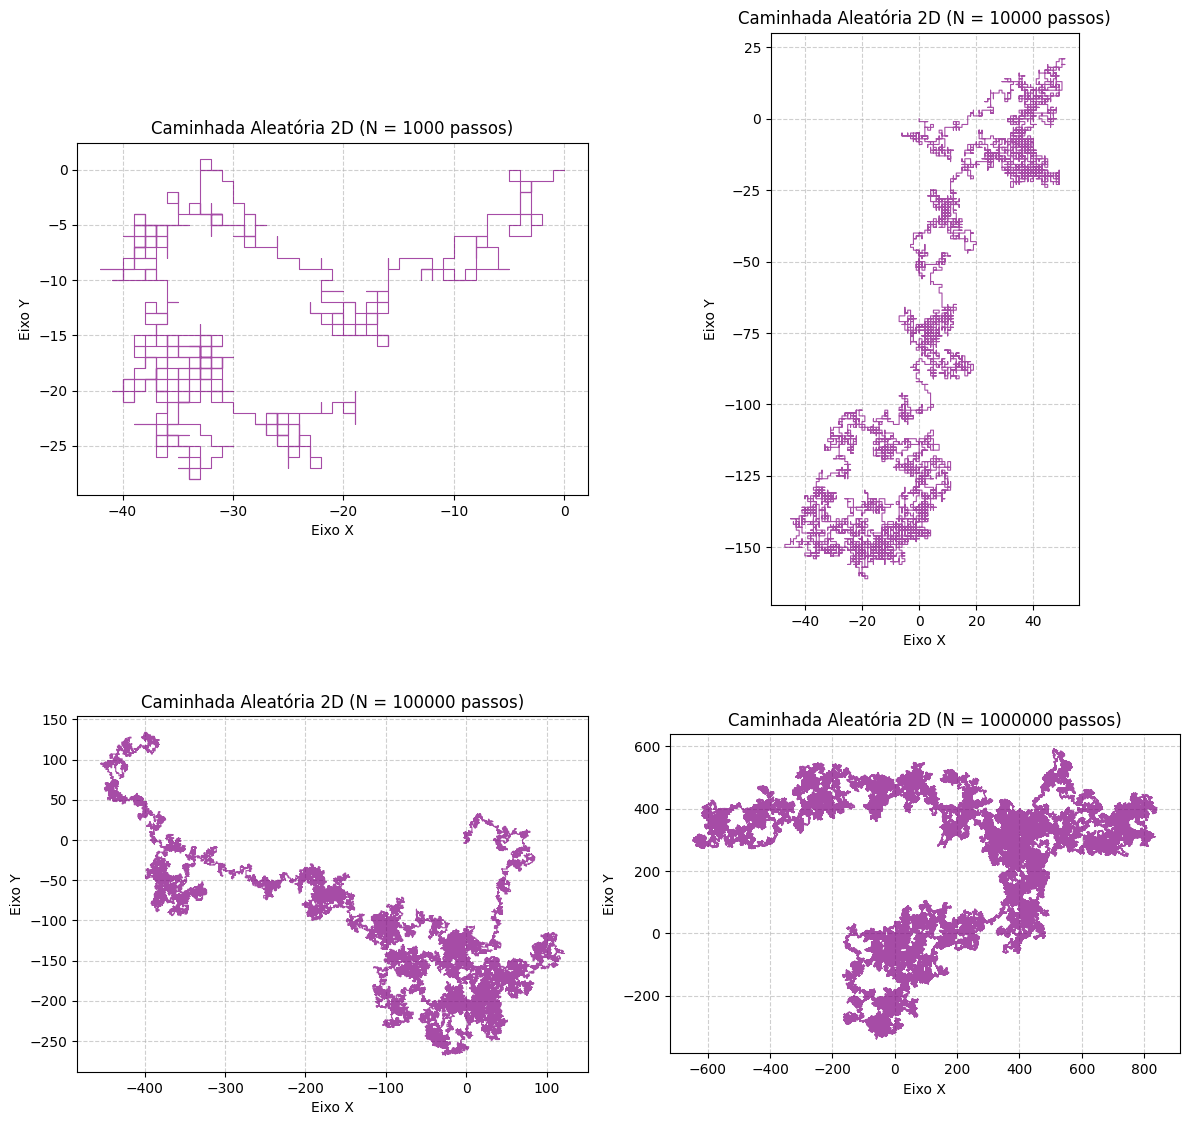

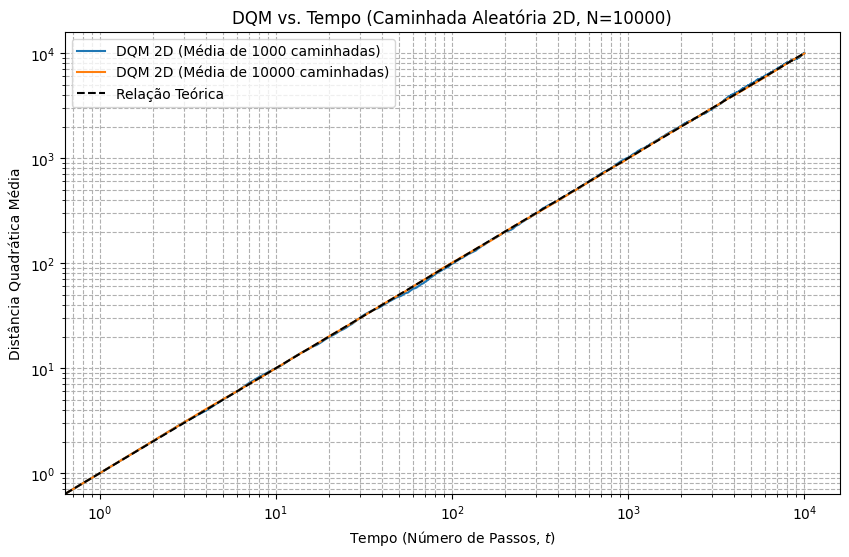

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random

def gerar_caminho(N):
  # inicia a caminhada na origem (0,0)
  x_posicoes = [0]
  y_posicoes = [0]
  x, y = 0, 0
  for n in range(N):
    direcao = random.randint(0, 3)
    if direcao == 0: # direita
      x = x + 1
    elif direcao == 1: # esquerda
      x = x - 1
    elif direcao == 2: # cima
      y = y + 1
    else:              # baixo
      y = y - 1
    x_posicoes.append(x) # atualiza x e y
    y_posicoes.append(y)
  # retorna o mapa de x e y dessa caminhada
  return np.array(x_posicoes), np.array(y_posicoes)

# essa função pega a lista que contem a quantidade de passo que quero plotar
def plotar_caminhada(lista_N):
  fig, axes = plt.subplots(2, 2, figsize=(12, 12))
  axes = axes.ravel() # transforma a matriz 2x2 numa lista de 4 eixos
  # o enumerate pega cada indice e seu valor dado numa lista
  for i, N in enumerate(lista_N):
    # usa a função criada acima para gerar um lista x e y
    x, y = gerar_caminho(N)
    # pegar o subplot correspondente do indice
    ax = axes[i]
    # plotar essas listas
    ax.plot(x, y, color='purple', alpha=0.7, lw=0.8)
    ax.set_title(f'Caminhada Aleatória 2D (N = {N} passos)')
    ax.set_xlabel('Eixo X')
    ax.set_ylabel('Eixo Y')
    ax.grid(True, linestyle='--', alpha=0.6)
    # isso impede que o grafico fique distorcido
    ax.set_aspect('equal', 'box')
  plt.tight_layout()
  plt.show()

lista_n_para_plotar = [1000, 10000, 100000, 1000000]
plotar_caminhada(lista_n_para_plotar)

# IDEIA: A distância média (ao quadrado) que o caminhante se afasta do início é diretamente proporcional ao número de passos que ele dá

# pega o numero de passos N, e a quantidade de simulações M
def plotar_dqm(N, lista_M):
  plt.figure(figsize=(10, 6))
  # cria o eixo x com numeros de 0 ate n-passos
  tempo = np.arange(N + 1)
  # repete para a quantidade de simulações dada
  for M in lista_M:
    # cria um array vazio de N lugares, um pra cada passo
    sdq = np.zeros(N + 1)
    # repete para essa quantidade de simulações
    for i in range(M):
      # cada simulação gera um historico dqm
      # usar a função para gerar um caminho aleatorio
      # um array de N
      x, y = gerar_caminho(N)
      # somamos todos os relatorios de cada simulação, pelo seu indice
      # eleva ao quadrado cada coord pra livrar do sinal negativo e evitar que direções opostas se anulem
      dqm = x**2 + y**2
      sdq += dqm
    # queremos a media daquele valor, independente do numero de simulações
    # divide elemento a elemento de forma vetorizada
    # resultado num array
    msd = sdq / M
    plt.plot(tempo, msd, label=f'DQM 2D (Média de {M} caminhadas)')
  plt.loglog(tempo, tempo, 'k--', label='Relação Teórica')
  plt.title(f'DQM vs. Tempo (Caminhada Aleatória 2D, N={N})')
  plt.xlabel('Tempo (Número de Passos, $t$)')
  plt.ylabel('Distância Quadrática Média')
  plt.legend()
  plt.grid(True, which="both", ls="--")
  plt.show()

N_dqm = 10000
M_dqm = [1000, 10000]
plotar_dqm(N_dqm, M_dqm)


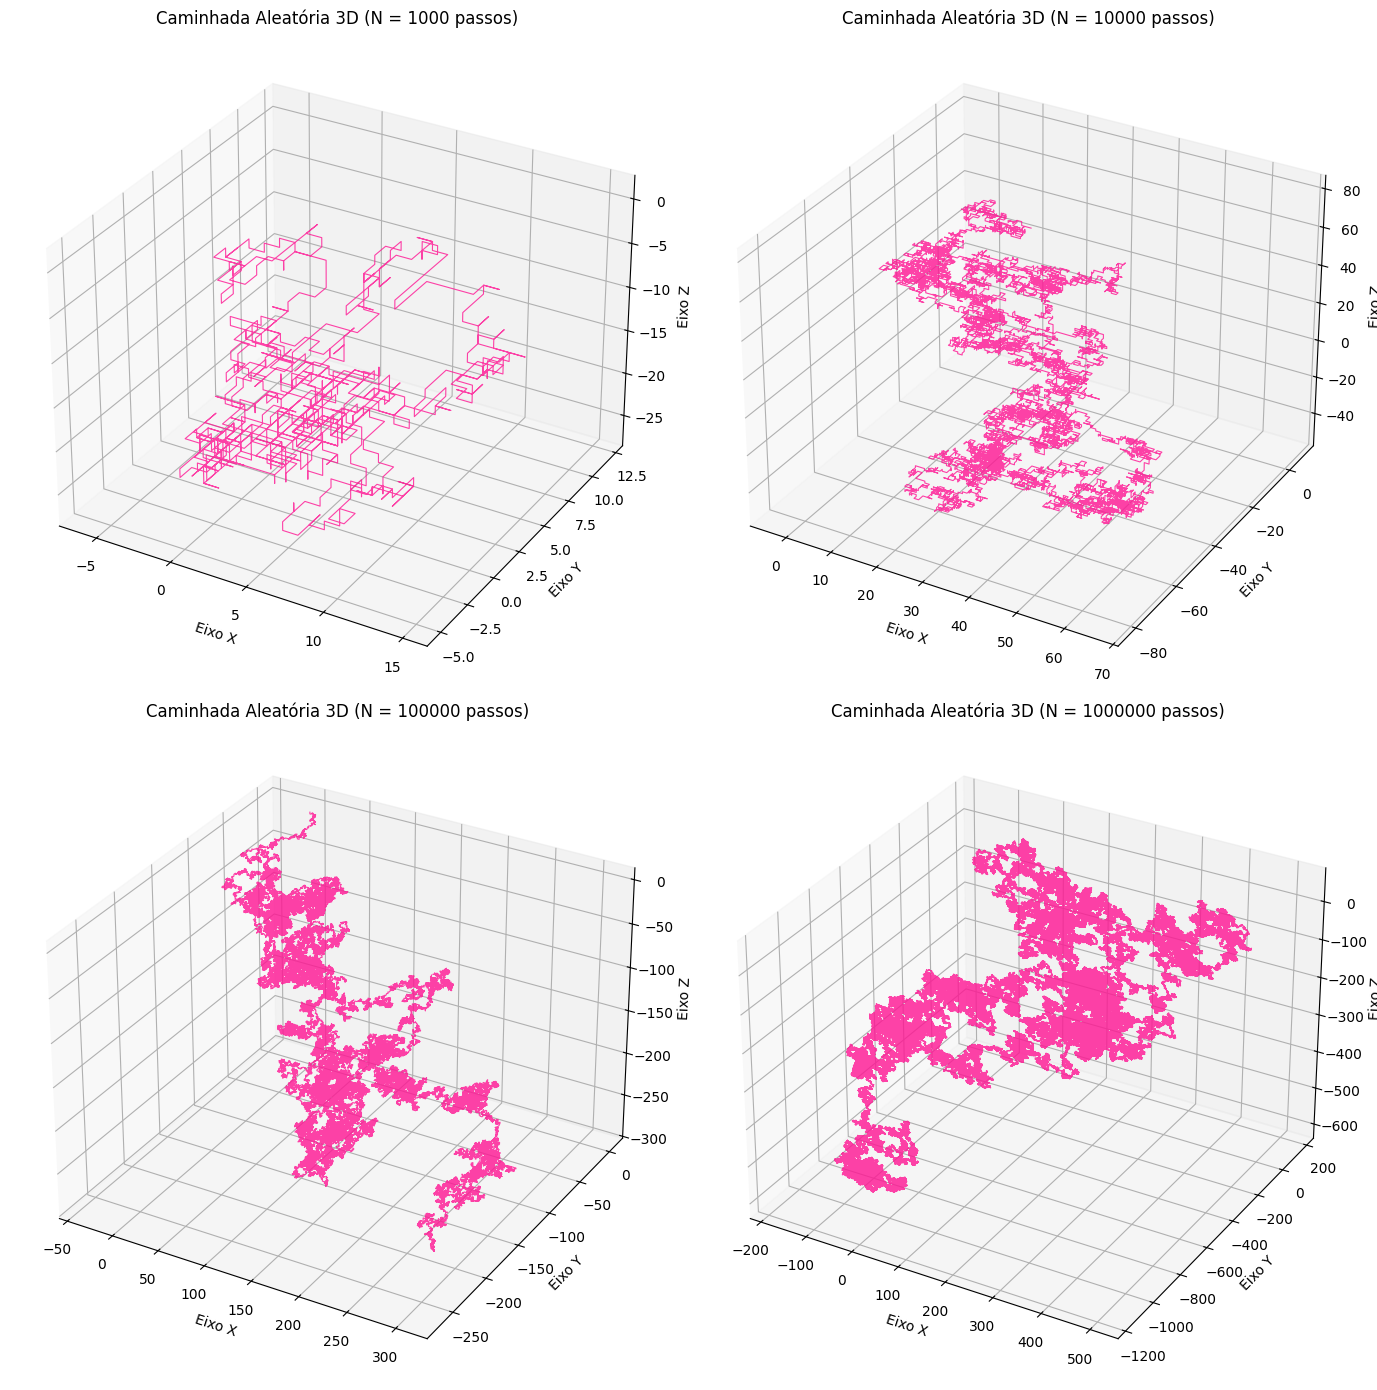

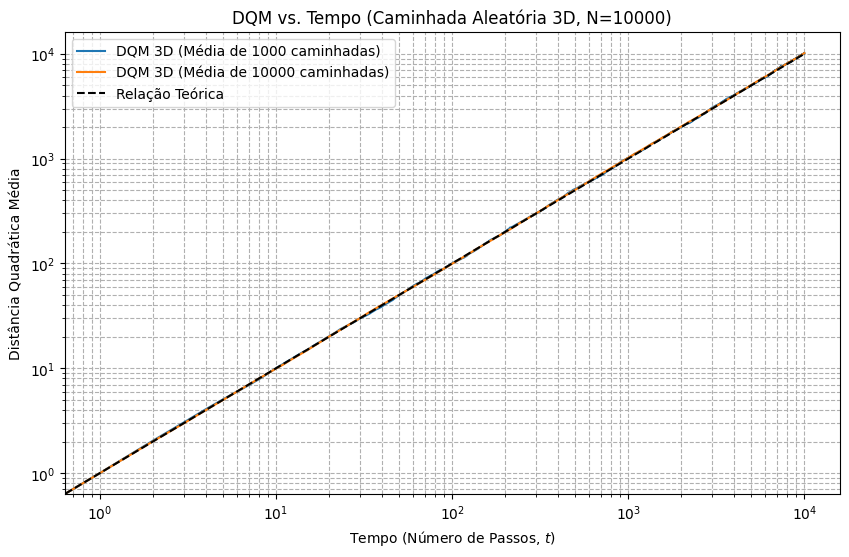

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random

def gerar_caminho_3d(n_passos):
  x_posicoes = [0]
  y_posicoes = [0]
  z_posicoes = [0]
  x, y, z = 0, 0, 0
  for _ in range(n_passos):
    direcao = random.randint(0, 5)
    if direcao == 0:
      x += 1
    elif direcao == 1:
      x -= 1
    elif direcao == 2:
      y += 1
    elif direcao == 3:
      y -= 1
    elif direcao == 4:
      z += 1
    else:
      z -= 1
    x_posicoes.append(x)
    y_posicoes.append(y)
    z_posicoes.append(z)
  return np.array(x_posicoes), np.array(y_posicoes), np.array(z_posicoes)

def plotar_caminhada_3d(lista_n_passos):
  fig = plt.figure(figsize=(14, 14))
  for i, n_passos in enumerate(lista_n_passos):
    x, y, z = gerar_caminho_3d(n_passos)
    ax = fig.add_subplot(2, 2, i + 1, projection='3d')
    ax.plot(x, y, z, color='deeppink', alpha=0.8, lw=0.8)
    ax.set_title(f'Caminhada Aleatória 3D (N = {n_passos} passos)')
    ax.set_xlabel('Eixo X')
    ax.set_ylabel('Eixo Y')
    ax.set_zlabel('Eixo Z')
  plt.tight_layout()
  plt.show()

def plotar_dqm_3d(n_passos, lista_m_caminhadas):
  plt.figure(figsize=(10, 6))
  tempo = np.arange(n_passos + 1)
  for M in lista_m_caminhadas:
    soma_dist_quad = np.zeros(n_passos + 1)
    for _ in range(M):
      x, y, z = gerar_caminho_3d(n_passos)
      dist_quad = x**2 + y**2 + z**2
      soma_dist_quad += dist_quad
    dqm = soma_dist_quad / M
    plt.plot(tempo, dqm, label=f'DQM 3D (Média de {M} caminhadas)')
  plt.loglog(tempo, tempo, 'k--', label='Relação Teórica')
  plt.title(f'DQM vs. Tempo (Caminhada Aleatória 3D, N={n_passos})')
  plt.xlabel('Tempo (Número de Passos, $t$)')
  plt.ylabel('Distância Quadrática Média')
  plt.legend()
  plt.grid(True, which="both", ls="--")
  plt.show()

lista_n_para_plotar_3d = [1000, 10000, 100000, 1000000]
plotar_caminhada_3d(lista_n_para_plotar_3d)

n_passos_dqm_3d = 10000
caminhada_dqm_3d = [1000, 10000]
plotar_dqm_3d(n_passos_dqm_3d, caminhada_dqm_3d)